In [1]:
import pandas as pd

# Load the datasets into pandas DataFrames
patients_df = pd.read_csv('patients.csv')
admission_df = pd.read_csv('admissions.csv')
icustays_df = pd.read_csv('icustays.csv')
diagnoses_icd_df = pd.read_csv('diagnoses_icd.csv')
icd_categories_df = pd.read_csv('icd_categories.csv')

# Display the first few rows of each dataframe to inspect them
print("Patients DataFrame:")
print(patients_df.head())

print("\nAdmission DataFrame:")
print(admission_df.head())

print("\nICU Stays DataFrame:")
print(icustays_df.head())

print("\nDiagnoses ICD DataFrame:")
print(diagnoses_icd_df.head())

print("\nICD Categories DataFrame:")
print(icd_categories_df.head())


Patients DataFrame:
   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10000032      F          52         2180       2014 - 2016  2180-09-09
1    10000048      F          23         2126       2008 - 2010         NaN
2    10000068      F          19         2160       2008 - 2010         NaN
3    10000084      M          72         2160       2017 - 2019  2161-02-13
4    10000102      F          27         2136       2008 - 2010         NaN

Admission DataFrame:
   subject_id   hadm_id            admittime            dischtime deathtime  \
0    10000032  22595853  2180-05-06 22:23:00  2180-05-07 17:15:00       NaN   
1    10000032  22841357  2180-06-26 18:27:00  2180-06-27 18:49:00       NaN   
2    10000032  25742920  2180-08-05 23:44:00  2180-08-07 17:50:00       NaN   
3    10000032  29079034  2180-07-23 12:35:00  2180-07-25 17:55:00       NaN   
4    10000068  25022803  2160-03-03 23:16:00  2160-03-04 06:26:00       NaN   

   admission_type admit_pro

Removing Empty Rows and Columns

In [2]:
# Removing empty rows and columns 
patients_df = patients_df.dropna(how='all', axis=1)  
patients_df = patients_df.dropna(how='all', axis=0)  

admission_df = admission_df.dropna(how='all', axis=1)
admission_df = admission_df.dropna(how='all', axis=0)

icustays_df = icustays_df.dropna(how='all', axis=1)
icustays_df = icustays_df.dropna(how='all', axis=0)

diagnoses_icd_df = diagnoses_icd_df.dropna(how='all', axis=1)
diagnoses_icd_df = diagnoses_icd_df.dropna(how='all', axis=0)

icd_categories_df = icd_categories_df.dropna(how='all', axis=1)
icd_categories_df = icd_categories_df.dropna(how='all', axis=0)

# Display the shape of each dataframe to verify the changes
print(f"Patients DataFrame shape: {patients_df.shape}")
print(f"Admission DataFrame shape: {admission_df.shape}")
print(f"ICU Stays DataFrame shape: {icustays_df.shape}")
print(f"Diagnoses ICD DataFrame shape: {diagnoses_icd_df.shape}")
print(f"ICD Categories DataFrame shape: {icd_categories_df.shape}")


Patients DataFrame shape: (299712, 6)
Admission DataFrame shape: (431231, 16)
ICU Stays DataFrame shape: (73181, 8)
Diagnoses ICD DataFrame shape: (4756326, 5)
ICD Categories DataFrame shape: (111863, 4)


Handling Missing Values

In [3]:
# Check for missing values in each dataset
print("Patients DataFrame missing values:")
print(patients_df.isnull().sum())

print("\nAdmission DataFrame missing values:")
print(admission_df.isnull().sum())

print("\nICU Stays DataFrame missing values:")
print(icustays_df.isnull().sum())

print("\nDiagnoses ICD DataFrame missing values:")
print(diagnoses_icd_df.isnull().sum())

print("\nICD Categories DataFrame missing values:")
print(icd_categories_df.isnull().sum())


Patients DataFrame missing values:
subject_id                0
gender                    0
anchor_age                0
anchor_year               0
anchor_year_group         0
dod                  270636
dtype: int64

Admission DataFrame missing values:
subject_id                   0
hadm_id                      0
admittime                    0
dischtime                    0
deathtime               422633
admission_type               0
admit_provider_id            4
admission_location           0
discharge_location      119155
insurance                    0
language                     0
marital_status            9233
race                         0
edregtime               131949
edouttime               131949
hospital_expire_flag         0
dtype: int64

ICU Stays DataFrame missing values:
subject_id        0
hadm_id           0
stay_id           0
first_careunit    0
last_careunit     0
intime            0
outtime           0
los               0
dtype: int64

Diagnoses ICD DataFrame mis

Filling or Dropping Missing Values

In [4]:
# filling missing values in categorical columns with 'Unknown'
patients_df['gender'] = patients_df['gender'].fillna('Unknown')

# Dropping rows with missing values for columns that are critical (e.g., subject_id)
admission_df = admission_df.dropna(subset=['subject_id', 'hadm_id'])

# Filling missing values for numerical columns (e.g., age) with the mean
icustays_df['los'] = icustays_df['los'].fillna(icustays_df['los'].mean())

# Dropping rows where the ICD code is missing in the Diagnoses dataset
diagnoses_icd_df = diagnoses_icd_df.dropna(subset=['icd_code'])

# Verify again after handling missing values
print("\nPatients DataFrame missing values after handling:")
print(patients_df.isnull().sum())

print("\nAdmission DataFrame missing values after handling:")
print(admission_df.isnull().sum())

print("\nICU Stays DataFrame missing values after handling:")
print(icustays_df.isnull().sum())

print("\nDiagnoses ICD DataFrame missing values after handling:")
print(diagnoses_icd_df.isnull().sum())

print("\nICD Categories DataFrame missing values after handling:")
print(icd_categories_df.isnull().sum())



Patients DataFrame missing values after handling:
subject_id                0
gender                    0
anchor_age                0
anchor_year               0
anchor_year_group         0
dod                  270636
dtype: int64

Admission DataFrame missing values after handling:
subject_id                   0
hadm_id                      0
admittime                    0
dischtime                    0
deathtime               422633
admission_type               0
admit_provider_id            4
admission_location           0
discharge_location      119155
insurance                    0
language                     0
marital_status            9233
race                         0
edregtime               131949
edouttime               131949
hospital_expire_flag         0
dtype: int64

ICU Stays DataFrame missing values after handling:
subject_id        0
hadm_id           0
stay_id           0
first_careunit    0
last_careunit     0
intime            0
outtime           0
los            

Handling Missing Data

In [5]:
# Filling missing values in columns with categorical data
patients_df['dod'] = patients_df['dod'].fillna('Alive')  

# For Admission DataFrame
admission_df['deathtime'] = admission_df['deathtime'].fillna('Alive')  # If alive, mark as 'Alive'
admission_df['admission_location'] = admission_df['admission_location'].fillna('Unknown')
admission_df['discharge_location'] = admission_df['discharge_location'].fillna('Unknown')
admission_df['marital_status'] = admission_df['marital_status'].fillna('Unknown')

# Check again after filling missing values
print("\nPatients DataFrame missing values after handling:")
print(patients_df.isnull().sum())

print("\nAdmission DataFrame missing values after handling:")
print(admission_df.isnull().sum())

# For the other dataframes (ICU stays, Diagnoses, ICD Categories), there are no missing values.



Patients DataFrame missing values after handling:
subject_id           0
gender               0
anchor_age           0
anchor_year          0
anchor_year_group    0
dod                  0
dtype: int64

Admission DataFrame missing values after handling:
subject_id                   0
hadm_id                      0
admittime                    0
dischtime                    0
deathtime                    0
admission_type               0
admit_provider_id            4
admission_location           0
discharge_location           0
insurance                    0
language                     0
marital_status               0
race                         0
edregtime               131949
edouttime               131949
hospital_expire_flag         0
dtype: int64


Handling Remaining Missing Values

In [6]:
# Handle remaining missing values in the Admission DataFrame

# Fill missing values for 'admit_provider_id' with 'Unknown'
admission_df['admit_provider_id'] = admission_df['admit_provider_id'].fillna('Unknown')

# Fill missing 'edregtime' and 'edouttime' with 'Unknown' 
admission_df['edregtime'] = admission_df['edregtime'].fillna('Unknown')
admission_df['edouttime'] = admission_df['edouttime'].fillna('Unknown')

# Verify after filling missing values
print("\nAdmission DataFrame missing values after handling:")
print(admission_df.isnull().sum())



Admission DataFrame missing values after handling:
subject_id              0
hadm_id                 0
admittime               0
dischtime               0
deathtime               0
admission_type          0
admit_provider_id       0
admission_location      0
discharge_location      0
insurance               0
language                0
marital_status          0
race                    0
edregtime               0
edouttime               0
hospital_expire_flag    0
dtype: int64


Outlier Detection

Boxplot Visualization for Outliers

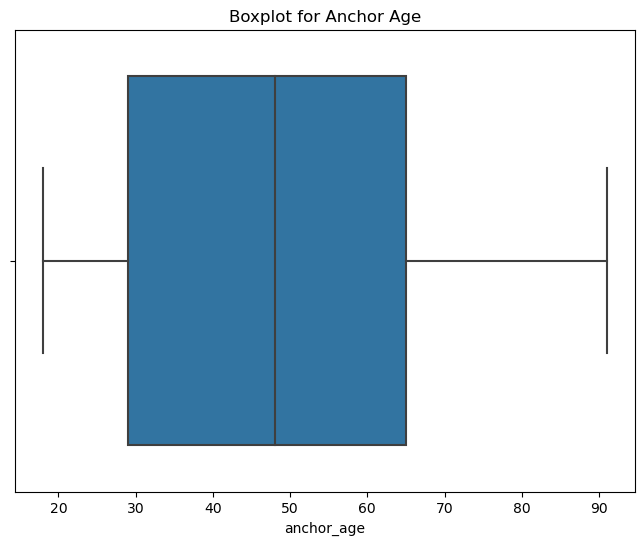

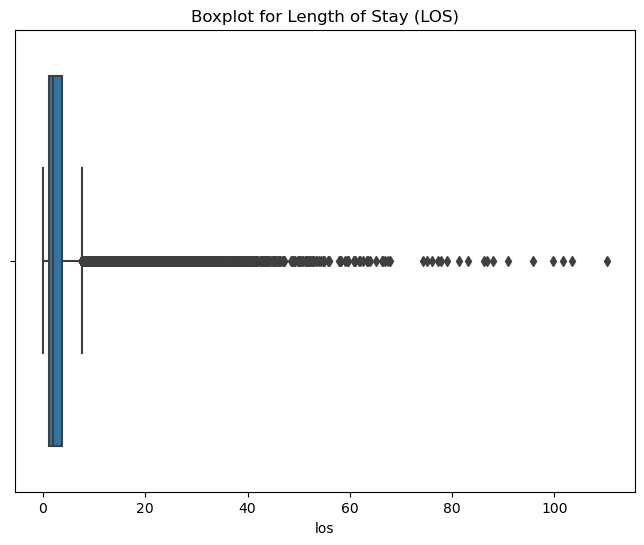

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot to check for outliers in anchor_age (age of the patient)
plt.figure(figsize=(8, 6))
sns.boxplot(x=patients_df['anchor_age'])
plt.title('Boxplot for Anchor Age')
plt.show()

# Boxplot to check for outliers in length of stay (los)
plt.figure(figsize=(8, 6))
sns.boxplot(x=icustays_df['los'])
plt.title('Boxplot for Length of Stay (LOS)')
plt.show()


Z-score for Numerical Outliers

In [8]:
from scipy import stats

# Calculate z-scores for anchor_age and los
z_scores_age = stats.zscore(patients_df['anchor_age'].dropna())
z_scores_los = stats.zscore(icustays_df['los'].dropna())

# Identify outliers where z-score is greater than 3 or less than -3
age_outliers = patients_df[abs(z_scores_age) > 3]
los_outliers = icustays_df[abs(z_scores_los) > 3]

# Display the number of outliers for both columns
print(f"Number of outliers in anchor_age: {len(age_outliers)}")
print(f"Number of outliers in LOS: {len(los_outliers)}")


print("\nOutliers in anchor_age:")
print(age_outliers)

print("\nOutliers in LOS:")
print(los_outliers)


Number of outliers in anchor_age: 0
Number of outliers in LOS: 1559

Outliers in anchor_age:
Empty DataFrame
Columns: [subject_id, gender, anchor_age, anchor_year, anchor_year_group, dod]
Index: []

Outliers in LOS:
       subject_id   hadm_id   stay_id  \
57       10007818  22987108  32359580   
126      10017531  21095812  32136798   
127      10017531  22580355  35526828   
196      10024982  25154057  37919901   
244      10032381  20176432  34622731   
...           ...       ...       ...   
72969    19971771  26230047  38668070   
73023    19982539  23136520  31123584   
73083    19989783  26984195  32761676   
73138    19995595  21784060  34670930   
73151    19997367  20617667  35616526   

                                         first_careunit  \
57                   Medical Intensive Care Unit (MICU)   
126    Medical/Surgical Intensive Care Unit (MICU/SICU)   
127    Medical/Surgical Intensive Care Unit (MICU/SICU)   
196                            Coronary Care Unit (CCU)

TASK 1: Understanding Length of Stay at the hospital

In [9]:
import pandas as pd

# Load the datasets
patients = pd.read_csv('patients.csv')
icustays = pd.read_csv('icustays.csv')
admissions = pd.read_csv('admissions.csv')
icd_categories = pd.read_csv('icd_categories.csv')

# Check the first few rows of each dataset
print(patients.head())
print(icustays.head())
print(admissions.head())
print(icd_categories.head())


   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10000032      F          52         2180       2014 - 2016  2180-09-09
1    10000048      F          23         2126       2008 - 2010         NaN
2    10000068      F          19         2160       2008 - 2010         NaN
3    10000084      M          72         2160       2017 - 2019  2161-02-13
4    10000102      F          27         2136       2008 - 2010         NaN
   subject_id   hadm_id   stay_id  \
0    10000032  29079034  39553978   
1    10000980  26913865  39765666   
2    10001217  24597018  37067082   
3    10001217  27703517  34592300   
4    10001725  25563031  31205490   

                                     first_careunit  \
0                Medical Intensive Care Unit (MICU)   
1                Medical Intensive Care Unit (MICU)   
2               Surgical Intensive Care Unit (SICU)   
3               Surgical Intensive Care Unit (SICU)   
4  Medical/Surgical Intensive Care Unit (MICU/

Calculate the Length of Stay

In [10]:
# Convert the datetime columns to pandas datetime format
admissions['admittime'] = pd.to_datetime(admissions['admittime'], errors='coerce')
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'], errors='coerce')
admissions['deathtime'] = pd.to_datetime(admissions['deathtime'], errors='coerce')

# Define a function to calculate length of stay
def calculate_los(row):
    if pd.notnull(row['dischtime']) and row['dischtime'] > row['deathtime']:
        return (row['admittime'] - row['deathtime']).total_seconds() / 86400  # Convert to days
    elif pd.notnull(row['dischtime']):
        return (row['dischtime'] - row['admittime']).total_seconds() / 86400  # Convert to days
    elif pd.notnull(row['deathtime']):
        return (row['deathtime'] - row['admittime']).total_seconds() / 86400  # Convert to days
    else:
        return None  

# Apply the function to each row and create the new column 'length_of_stay'
admissions['length_of_stay'] = admissions.apply(calculate_los, axis=1)

# Check the new column
print(admissions[['admittime', 'dischtime', 'deathtime', 'length_of_stay']].head())


            admittime           dischtime deathtime  length_of_stay
0 2180-05-06 22:23:00 2180-05-07 17:15:00       NaT        0.786111
1 2180-06-26 18:27:00 2180-06-27 18:49:00       NaT        1.015278
2 2180-08-05 23:44:00 2180-08-07 17:50:00       NaT        1.754167
3 2180-07-23 12:35:00 2180-07-25 17:55:00       NaT        2.222222
4 2160-03-03 23:16:00 2160-03-04 06:26:00       NaT        0.298611


 Identify and Remove Outliers Based on Standard Deviation



In [11]:
# Calculate mean and standard deviation
mean_los = admissions['length_of_stay'].mean()
std_los = admissions['length_of_stay'].std()

# Identify outliers (more than 3 standard deviations away)
outliers = admissions[(admissions['length_of_stay'] > mean_los + 3 * std_los) | 
                      (admissions['length_of_stay'] < mean_los - 3 * std_los)]

# Drop the outliers from the dataframe
admissions_cleaned = admissions[(admissions['length_of_stay'] <= mean_los + 3 * std_los) & 
                                (admissions['length_of_stay'] >= mean_los - 3 * std_los)]

# Check the number of rows before and after removing outliers
print(f"Original number of rows: {len(admissions)}")
print(f"Number of rows after removing outliers: {len(admissions_cleaned)}")

Original number of rows: 431231
Number of rows after removing outliers: 423667


 Plot a Histogram of Length of Stay (LOS)

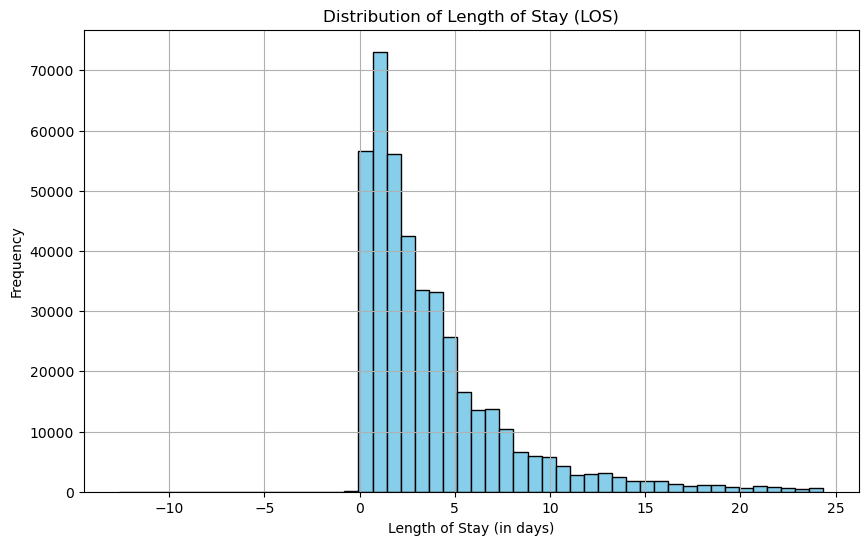

In [12]:
import matplotlib.pyplot as plt

# Plot histogram of Length of Stay with 50 bins (you can adjust the number of bins)
plt.figure(figsize=(10, 6))
admissions_cleaned['length_of_stay'].plot.hist(bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Length of Stay (LOS)')
plt.xlabel('Length of Stay (in days)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Plot Histogram with Logarithmic Scale

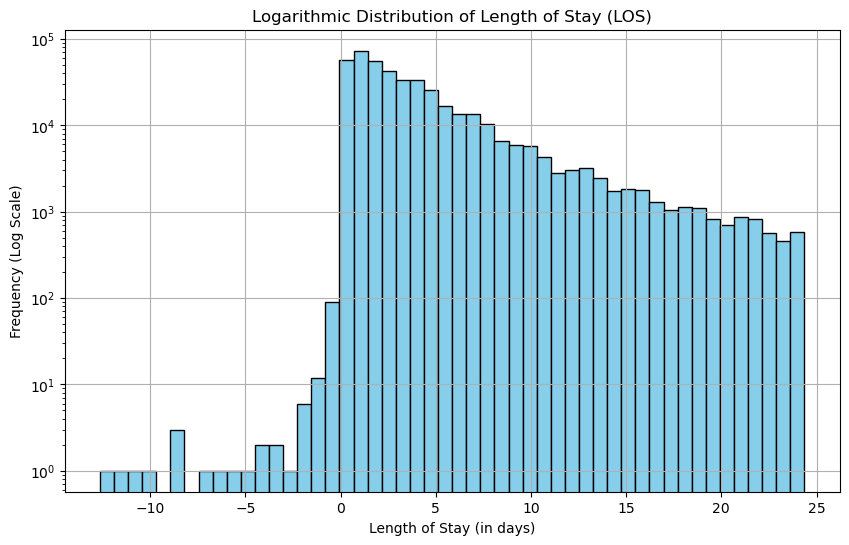

In [13]:
# Plot histogram of Length of Stay with logarithmic scale for the y-axis
plt.figure(figsize=(10, 6))
admissions_cleaned['length_of_stay'].plot.hist(bins=50, edgecolor='black', color='skyblue')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Logarithmic Distribution of Length of Stay (LOS)')
plt.xlabel('Length of Stay (in days)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(True)
plt.show()

 Count Unique Races and Create Super Categories

In [14]:
admissions_cleaned = admissions_cleaned.copy()

# Apply the ethnicity replacement as before
admissions_cleaned.loc[:, "ethnicity"] = admissions_cleaned["race"].replace({
    r"^AMERICAN\D*": "AMERICAN INDIAN",
    r"^ASIAN\D*": "ASIAN",
    r"^WHITE\D*": "WHITE",
    r"^HISPANIC\D*": "HISPANIC/LATINO",
    r"^BLACK\D*": "BLACK",
    r"^UNKNOWN\D*|^UNABLE\D*|^MULTIPLE\D*|^PATIENT\D*|^OTHER\D*": "UNKNOWN",
    r"^NATIVE\D*": "NATIVE HAWAIIAN"
}, regex=True)

# Check the unique values in the 'ethnicity' column again
unique_ethnicities = admissions_cleaned['ethnicity'].unique()
print(f"Unique ethnicities after fix: {unique_ethnicities}")

Unique ethnicities after fix: ['WHITE' 'UNKNOWN' 'BLACK' 'PORTUGUESE' 'ASIAN' 'HISPANIC/LATINO'
 'NATIVE HAWAIIAN' 'AMERICAN INDIAN' 'SOUTH AMERICAN']


In [15]:
# Group 'PORTUGUESE' and 'SOUTH AMERICAN' into 'LATIN AMERICAN'
admissions_cleaned['ethnicity'] = admissions_cleaned['ethnicity'].replace({
    'PORTUGUESE': 'LATIN AMERICAN',
    'SOUTH AMERICAN': 'LATIN AMERICAN'
})

# Check the unique ethnicities again
unique_ethnicities = admissions_cleaned['ethnicity'].unique()
print(f"Unique ethnicities after grouping: {unique_ethnicities}")

Unique ethnicities after grouping: ['WHITE' 'UNKNOWN' 'BLACK' 'LATIN AMERICAN' 'ASIAN' 'HISPANIC/LATINO'
 'NATIVE HAWAIIAN' 'AMERICAN INDIAN']


Plotting the Distribution of Ethnicity

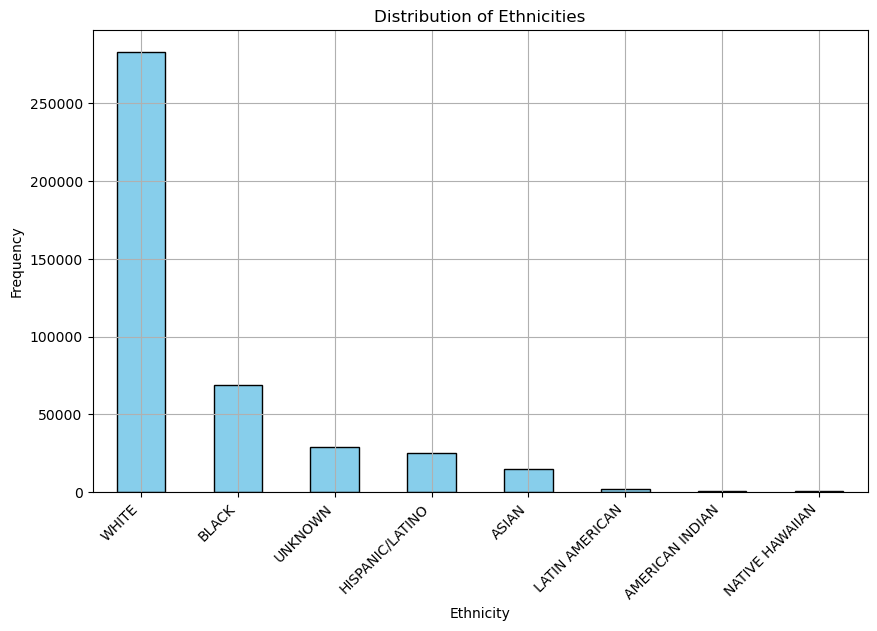

In [16]:
# Plot the distribution of ethnicity categories
plt.figure(figsize=(10, 6))
admissions_cleaned['ethnicity'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Ethnicities')
plt.xlabel('Ethnicity')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

TASK 2: Contributing factors to the length of stay

Step 1: Plotting Average Length of Stay by Ethnicity

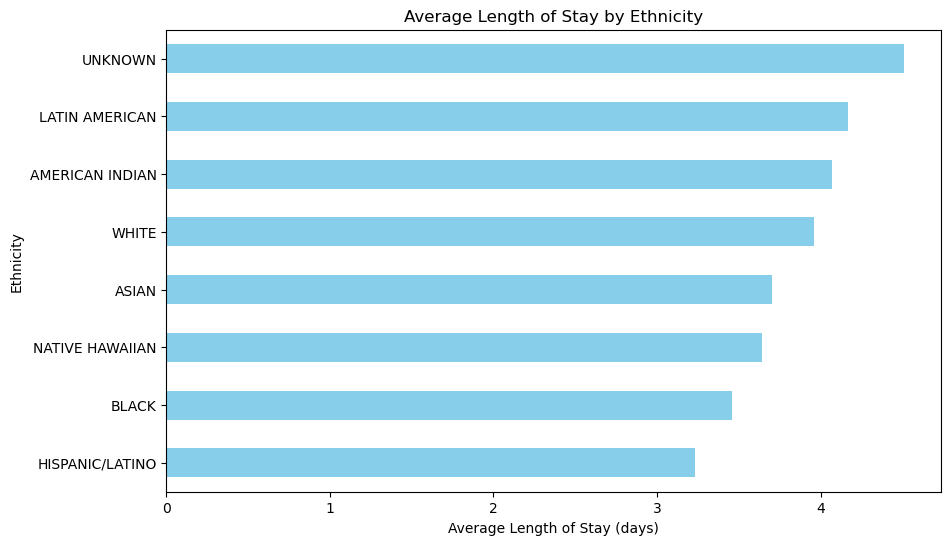

In [17]:
import matplotlib.pyplot as plt

# Group by ethnicity and calculate the average length of stay
avg_los_by_ethnicity = admissions_cleaned.groupby("ethnicity")["length_of_stay"].mean().sort_values()

# Plot horizontal bar graph
avg_los_by_ethnicity.plot(kind='barh', color='skyblue', figsize=(10, 6))
plt.title('Average Length of Stay by Ethnicity')
plt.xlabel('Average Length of Stay (days)')
plt.ylabel('Ethnicity')
plt.show()

Read patients dataset and merge it with admissions dataset

In [18]:
# Merge admissions and patients datasets on 'subject_id'
merged_data = pd.merge(admissions_cleaned, patients, on='subject_id', how='left')

# Check the first few rows of merged_data to confirm the merge was successful
merged_data.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,edregtime,edouttime,hospital_expire_flag,length_of_stay,ethnicity,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,...,2180-05-06 19:17:00,2180-05-06 23:30:00,0,0.786111,WHITE,F,52,2180,2014 - 2016,2180-09-09
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,P09Q6Y,EMERGENCY ROOM,HOME,Medicaid,...,2180-06-26 15:54:00,2180-06-26 21:31:00,0,1.015278,WHITE,F,52,2180,2014 - 2016,2180-09-09
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,P60CC5,EMERGENCY ROOM,HOSPICE,Medicaid,...,2180-08-05 20:58:00,2180-08-06 01:44:00,0,1.754167,WHITE,F,52,2180,2014 - 2016,2180-09-09
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT,EW EMER.,P30KEH,EMERGENCY ROOM,HOME,Medicaid,...,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2.222222,WHITE,F,52,2180,2014 - 2016,2180-09-09
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaT,EU OBSERVATION,P51VDL,EMERGENCY ROOM,NaN,Other,...,2160-03-03 21:55:00,2160-03-04 06:26:00,0,0.298611,WHITE,F,19,2160,2008 - 2010,NaN


Horizontal bar graph for admission_type

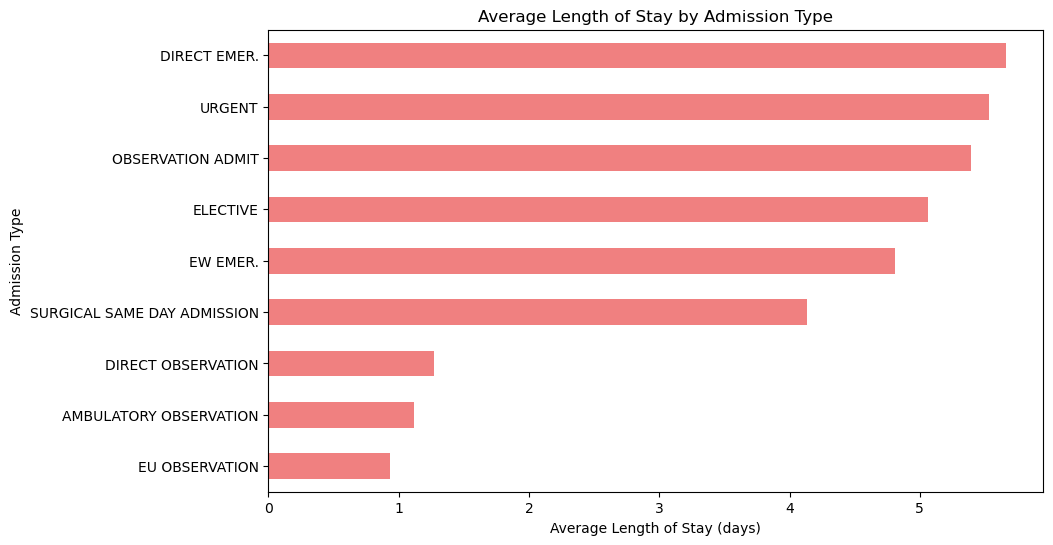

In [19]:
# Group by admission type and calculate the average length of stay
avg_los_by_admission_type = merged_data.groupby("admission_type")["length_of_stay"].mean().sort_values()

# Plot horizontal bar graph
avg_los_by_admission_type.plot(kind='barh', color='lightcoral', figsize=(10, 6))
plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Average Length of Stay (days)')
plt.ylabel('Admission Type')
plt.show()

The graph shows average Length of Stay (LOS) varies by admission type. Direct Emergent admissions have the longest LOS (around 5.5 days), followed by Urgent admissions (around 5 days). Elective admissions have a moderate LOS (around 4 days). Observation and Emergency admissions have shorter LOS, ranging from 1 to 4 days.

Gender-Based Analysis

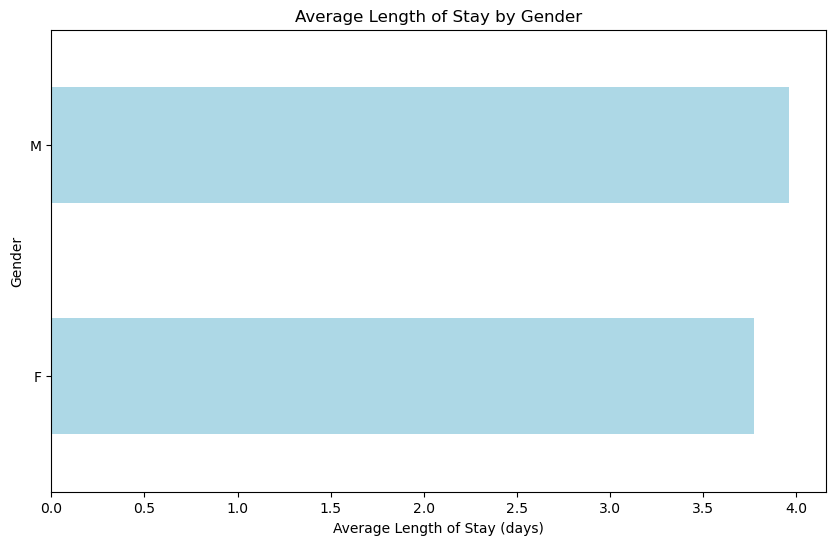

In [20]:
# Group by gender and calculate the average length of stay
avg_los_by_gender = merged_data.groupby("gender")["length_of_stay"].mean().sort_values()

# Plot horizontal bar graph
avg_los_by_gender.plot(kind='barh', color='lightblue', figsize=(10, 6))
plt.title('Average Length of Stay by Gender')
plt.xlabel('Average Length of Stay (days)')
plt.ylabel('Gender')
plt.show()


The graph shows a slight difference in average Length of Stay (LOS) between genders. Males have a slightly longer LOS (around 4 days) compared to females (around 3.5 days). However, this difference is minimal, suggesting gender might not be a significant factor in determining LOS in this dataset.

Age Group-Based Analysis

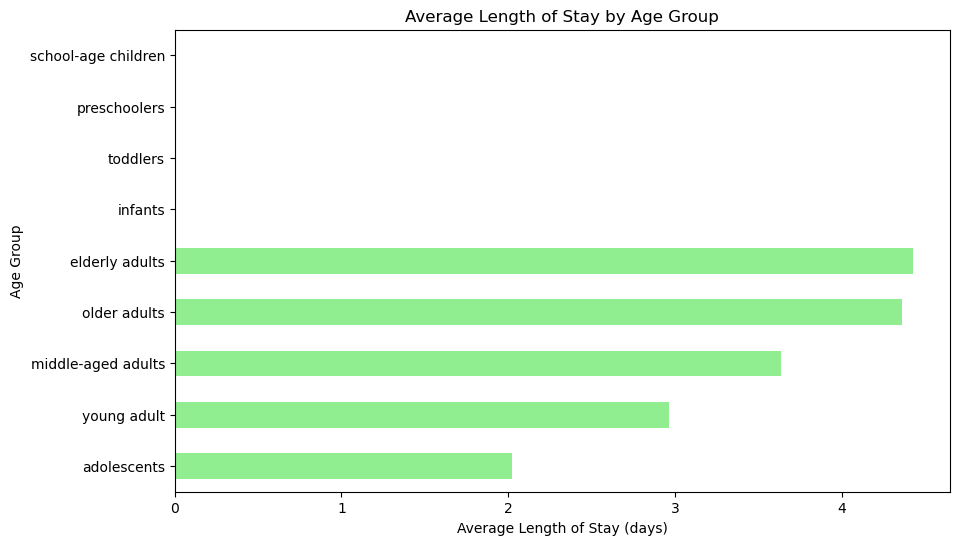

In [21]:
# Define the age groups using pd.cut()
bins = [0, 1, 3, 6, 12, 19, 39, 59, 79, 100]
labels = ['infants', 'toddlers', 'preschoolers', 'school-age children', 'adolescents', 
          'young adult', 'middle-aged adults', 'older adults', 'elderly adults']

# Create the age_group column
merged_data['age_group'] = pd.cut(merged_data['anchor_age'], bins=bins, labels=labels, right=False)

# Group by age_group and calculate the average length of stay
avg_los_by_age_group = merged_data.groupby("age_group")["length_of_stay"].mean().sort_values()

# Plot horizontal bar graph
avg_los_by_age_group.plot(kind='barh', color='lightgreen', figsize=(10, 6))
plt.title('Average Length of Stay by Age Group')
plt.xlabel('Average Length of Stay (days)')
plt.ylabel('Age Group')
plt.show()

In [22]:
print(admissions_cleaned.columns)


Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'length_of_stay',
       'ethnicity'],
      dtype='object')


In [23]:
# Check the columns in the 'patients' dataset
print(patients.columns)


Index(['subject_id', 'gender', 'anchor_age', 'anchor_year',
       'anchor_year_group', 'dod'],
      dtype='object')


In [24]:
import pandas as pd

# Define the age bins and the corresponding labels
age_bins = [0, 1, 3, 6, 13, 20, 40, 60, 80, float('inf')]
age_labels = ['infants', 'toddlers', 'preschoolers', 'school-age children', 
              'adolescents', 'young adult', 'middle-aged adults', 
              'older adults', 'elderly adults']

# Assuming 'anchor_age' column exists in the 'patients' DataFrame
patients['age_group'] = pd.cut(patients['anchor_age'], bins=age_bins, labels=age_labels, right=False)

# Check the result by displaying the first few rows
print(patients[['anchor_age', 'age_group']].head())


   anchor_age           age_group
0          52  middle-aged adults
1          23         young adult
2          19         adolescents
3          72        older adults
4          27         young adult


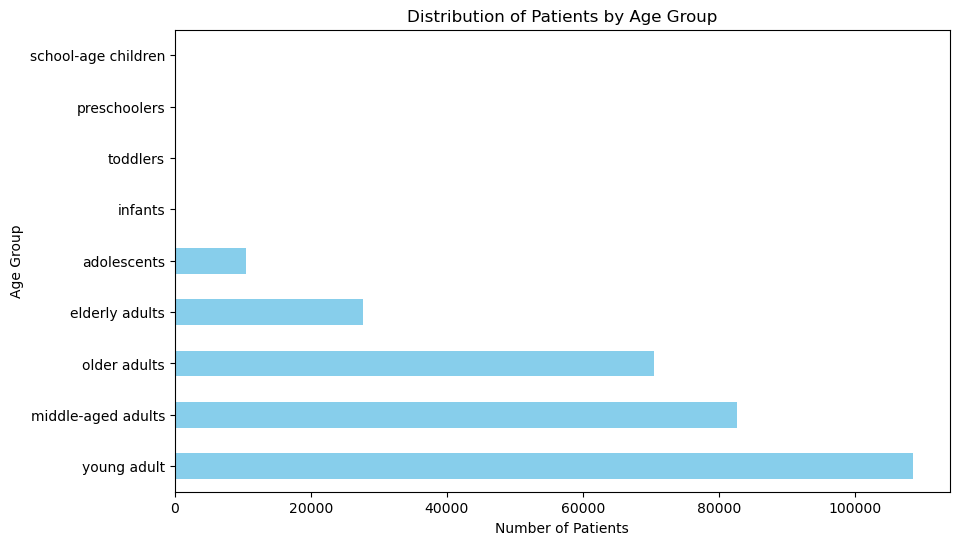

In [25]:
import matplotlib.pyplot as plt

# Plot horizontal bar graph for age groups
plt.figure(figsize=(10, 6))
patients['age_group'].value_counts().plot(kind='barh', color='skyblue')

# Adding labels and title
plt.title('Distribution of Patients by Age Group')
plt.xlabel('Number of Patients')
plt.ylabel('Age Group')

# Show the plot
plt.show()


Read the icd_categories.csv dataset and convert to categories

In [26]:
import pandas as pd

# Step 1: Read the icd_categories.csv dataset
icd_codes = pd.read_csv('icd_categories.csv')

# Step 2: Set the index to ['ICD_VERSION', 'DIAGNOSIS CODE'] to match the ICD data
icd_codes.set_index(["ICD_VERSION", "DIAGNOSIS CODE"], inplace=True)

# Step 3: Convert the 'SHORT_CATEGORY' column to a dictionary mapping (ICD_VERSION, DIAGNOSIS CODE) -> SHORT_CATEGORY
codes_to_category = icd_codes[["SHORT_CATEGORY"]].to_dict()["SHORT_CATEGORY"]

# Step 4: Reset the index
icd_codes.reset_index(inplace=True)

# Check the resulting dataframe (just for verification)
icd_codes.head()

,ICD_VERSION,DIAGNOSIS CODE,CATEGORY,SHORT_CATEGORY
0,9,10,Infectious And Parasitic Diseases,infectious
1,9,11,Infectious And Parasitic Diseases,infectious
2,9,19,Infectious And Parasitic Diseases,infectious
3,9,20,Infectious And Parasitic Diseases,infectious
4,9,21,Infectious And Parasitic Diseases,infectious


Read the diagnoses_icd.csv dataset and map the diagnosis categories

In [27]:
import pandas as pd

# Step 1: Read the datasets
diagnoses_icd = pd.read_csv('diagnoses_icd.csv')
icd_codes = pd.read_csv('icd_categories.csv')

# Step 2: Set the index to ['ICD_VERSION', 'DIAGNOSIS CODE'] to match the ICD data
icd_codes.set_index(['ICD_VERSION', 'DIAGNOSIS CODE'], inplace=True)

# Step 3: Create the mapping dictionary from 'ICD_VERSION' and 'DIAGNOSIS CODE' to 'SHORT_CATEGORY'
codes_to_category = icd_codes[['SHORT_CATEGORY']].to_dict()['SHORT_CATEGORY']

# Step 4: Reset the index of icd_codes (optional, if needed for further use)
icd_codes.reset_index(inplace=True)

# Step 5: Map the diagnosis category to the diagnoses_icd DataFrame
diagnoses_icd['diagnosis'] = diagnoses_icd.apply(
    lambda row: codes_to_category.get((row['icd_version'], row['icd_code']), None), axis=1
)

# Step 6: Drop rows with no valid diagnosis (if any)
diagnoses_icd = diagnoses_icd.dropna(subset=['diagnosis'])

# Check the resulting DataFrame
print(diagnoses_icd.head())



   subject_id   hadm_id  seq_num icd_code  icd_version    diagnosis
0    10000032  22595853        1     5723            9    digestive
1    10000032  22595853        2    78959            9  ill-defined
2    10000032  22595853        3     5715            9    digestive
4    10000032  22595853        5      496            9  respiratory
5    10000032  22595853        6    29680            9       mental


Group Diagnoses by hadm_id


In [28]:
# Group diagnoses for each unique hadm_id and subject_id
diagnosis = diagnoses_icd.groupby(["subject_id", "hadm_id"])["diagnosis"].apply(lambda x: list(set(x))).reset_index()

# Check the first few rows to ensure the grouping was successful
diagnosis.head()

,subject_id,hadm_id,diagnosis
0,10000032,22595853,"[respiratory, mental, external health issues, ..."
1,10000032,22841357,"[blood, respiratory, mental, external health i..."
2,10000032,25742920,"[respiratory, mental, external health issues, ..."
3,10000032,29079034,"[respiratory, mental, external health issues, ..."
4,10000068,25022803,[mental]


Merge admissions and diagnosis dataframes on subject_id and hadm_id, let's call it super dataset.

In [32]:
# Assuming admissions and diagnosis DataFrames are already loaded

# Merge the admissions and diagnosis DataFrames on subject_id and hadm_id
super_dataset = pd.merge(admissions, diagnosis, on=["subject_id", "hadm_id"], how="inner")

# Check the first few rows of the merged dataset
super_dataset.head()


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,length_of_stay,diagnosis
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,0.786111,"[respiratory, mental, external health issues, ..."
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,P09Q6Y,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,1.015278,"[blood, respiratory, mental, external health i..."
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,P60CC5,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,1.754167,"[respiratory, mental, external health issues, ..."
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT,EW EMER.,P30KEH,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2.222222,"[respiratory, mental, external health issues, ..."
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaT,EU OBSERVATION,P51VDL,EMERGENCY ROOM,NaN,Other,ENGLISH,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0,0.298611,[mental]


In [35]:
# Merge the admissions and patients dataframes on 'subject_id' to add 'gender' and 'age'
admissions = pd.merge(admissions, patients[['subject_id', 'gender', 'anchor_age']], on='subject_id', how='left')

# Step 2: Compute the 'length_of_stay' by calculating the difference between 'dischtime' and 'admittime'
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])

# Calculate the length of stay in days
admissions['length_of_stay'] = (admissions['dischtime'] - admissions['admittime']).dt.days

# Check the result
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,length_of_stay,gender,anchor_age
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,0,F,52
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,P09Q6Y,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,1,F,52
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,P60CC5,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,1,F,52
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT,EW EMER.,P30KEH,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2,F,52
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaT,EU OBSERVATION,P51VDL,EMERGENCY ROOM,NaN,Other,ENGLISH,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0,0,F,19


Convert gender into a numeric boolean attribute, where "M" = 0 and "F" = 1.


In [37]:
# Convert gender into numeric boolean attribute: "M" = 0, "F" = 1
admissions['gender'] = admissions['gender'].apply(lambda x: 0 if x == 'M' else 1)

# Check the updated dataframe
admissions[['subject_id', 'hadm_id', 'gender', 'length_of_stay']].head()


,subject_id,hadm_id,gender,length_of_stay
0,10000032,22595853,1,0
1,10000032,22841357,1,1
2,10000032,25742920,1,1
3,10000032,29079034,1,2
4,10000068,25022803,1,0


In [58]:
import pandas as pd

# Replace 'path_to_diagnoses_icd.csv' with the actual file path
diagnoses = pd.read_csv('diagnoses_icd.csv')

# Check if the dataset is loaded
print(diagnoses.head())
print(diagnoses.columns)



   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9
3    10000032  22595853        4    07070            9
4    10000032  22595853        5      496            9
Index(['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version'], dtype='object')


In [59]:
icd_codes = pd.read_csv('icd_categories.csv')  # Replace with actual file path
print(icd_codes.head())
print(icd_codes.columns)


   ICD_VERSION DIAGNOSIS CODE                           CATEGORY  \
0            9             10  Infectious And Parasitic Diseases   
1            9             11  Infectious And Parasitic Diseases   
2            9             19  Infectious And Parasitic Diseases   
3            9             20  Infectious And Parasitic Diseases   
4            9             21  Infectious And Parasitic Diseases   

  SHORT_CATEGORY  
0     infectious  
1     infectious  
2     infectious  
3     infectious  
4     infectious  
Index(['ICD_VERSION', 'DIAGNOSIS CODE', 'CATEGORY', 'SHORT_CATEGORY'], dtype='object')


In [60]:
icd_codes.set_index(['ICD_VERSION', 'DIAGNOSIS CODE'], inplace=True)
codes_to_category = icd_codes[['SHORT_CATEGORY']].to_dict()['SHORT_CATEGORY']
icd_codes.reset_index(inplace=True)


In [56]:
icd_codes = pd.read_csv('icd_categories.csv')
icd_codes.set_index(['ICD_VERSION', 'DIAGNOSIS CODE'], inplace=True)
codes_to_category = icd_codes[['SHORT_CATEGORY']].to_dict()['SHORT_CATEGORY']
icd_codes.reset_index(inplace=True)



In [55]:
# Print column names of diagnoses_icd dataframe
print(diagnoses_icd.columns)



Index(['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version',
       'diagnosis_name'],
      dtype='object')


In [51]:
# Create a mapping of (icd_version, icd_code) to SHORT_CATEGORY using icd_codes dataframe
icd_codes.set_index(["ICD_VERSION", "DIAGNOSIS CODE"], inplace=True)
codes_to_category = icd_codes[["SHORT_CATEGORY"]].to_dict()["SHORT_CATEGORY"]
icd_codes.reset_index(inplace=True)

# Merge ICD codes with diagnoses_icd to add diagnosis names
diagnoses_icd['diagnosis_name'] = diagnoses_icd.apply(
    lambda row: codes_to_category.get((row['icd_version'], row['icd_code']), None), axis=1
)

# Drop rows with missing diagnosis_name
diagnoses_icd.dropna(subset=['diagnosis_name'], inplace=True)



In [61]:
# One-hot encode the diagnosis column
one_hot_diagnosis = pd.get_dummies(super_data["diagnosis"].explode()).groupby(level=0).sum()

# Merge the one-hot encoded diagnosis back into the main dataset
super_data = pd.merge(super_data, one_hot_diagnosis, left_index=True, right_index=True)

# Drop the original diagnosis column
super_data.drop(columns=["diagnosis"], inplace=True)

print("After one-hot encoding diagnosis:")
print(super_data.head())


After one-hot encoding diagnosis:
   subject_id   hadm_id           admittime           dischtime deathtime  \
0    10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00       NaT   
1    10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00       NaT   
2    10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00       NaT   
3    10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00       NaT   
4    10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00       NaT   

   admission_type admit_provider_id      admission_location  \
0          URGENT            P874LG  TRANSFER FROM HOSPITAL   
1        EW EMER.            P09Q6Y          EMERGENCY ROOM   
2        EW EMER.            P60CC5          EMERGENCY ROOM   
3        EW EMER.            P30KEH          EMERGENCY ROOM   
4  EU OBSERVATION            P51VDL          EMERGENCY ROOM   

  discharge_location insurance  ... injury mental morbidity musculoskeletal  \
0               HOME     Other  ...      0   

In [63]:
print(super_data.columns)


Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'length_of_stay',
       'gender', 'anchor_age', 'age_group', 'abnormal findings', 'blood',
       'circulatory', 'congenital', 'digestive', 'ear', 'endocrine',
       'external health issues', 'eye', 'genitourinary', 'ill-defined',
       'infectious', 'injury', 'mental', 'morbidity', 'musculoskeletal',
       'neoplasms', 'nervous', 'perinatal', 'pregnancy', 'respiratory',
       'skin'],
      dtype='object')


In [64]:
super_data = pd.merge(admissions, diagnosis, on=['subject_id', 'hadm_id'], how='inner')

# Check if the required columns are present
print(super_data.columns)


Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'length_of_stay',
       'gender', 'anchor_age', 'diagnosis'],
      dtype='object')


In [66]:
# Check if diagnosis column contains lists
print(super_data['diagnosis'].head())

# One-hot encode the 'diagnosis' column
one_hot_diagnosis = pd.get_dummies(super_data["diagnosis"].explode()).groupby(level=0).sum()

# Merge the one-hot encoded diagnosis back into the main dataset
super_data = pd.merge(super_data, one_hot_diagnosis, left_index=True, right_index=True)

# Drop the original 'diagnosis' column
super_data.drop(columns=["diagnosis"], inplace=True)

print("After one-hot encoding 'diagnosis':")
print(super_data.head())



0    [respiratory, mental, external health issues, ...
1    [blood, respiratory, mental, external health i...
2    [respiratory, mental, external health issues, ...
3    [respiratory, mental, external health issues, ...
4                                             [mental]
Name: diagnosis, dtype: object
After one-hot encoding 'diagnosis':
   subject_id   hadm_id           admittime           dischtime deathtime  \
0    10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00       NaT   
1    10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00       NaT   
2    10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00       NaT   
3    10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00       NaT   
4    10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00       NaT   

   admission_type admit_provider_id      admission_location  \
0          URGENT            P874LG  TRANSFER FROM HOSPITAL   
1        EW EMER.            P09Q6Y          EMERGENCY ROOM   
2     

In [68]:
# Define age bins and labels
age_bins = [-1, 1, 2, 5, 12, 19, 39, 59, 79, float('inf')]
age_labels = ['infants', 'toddlers', 'preschoolers', 'school-age children',
              'adolescents', 'young adults', 'middle-aged adults',
              'older adults', 'elderly adults']

# Create the age_group column
super_data['age_group'] = pd.cut(super_data['anchor_age'], bins=age_bins, labels=age_labels)

print("Age group column added:")
print(super_data[['anchor_age', 'age_group']].head())



Age group column added:
   anchor_age           age_group
0          52  middle-aged adults
1          52  middle-aged adults
2          52  middle-aged adults
3          52  middle-aged adults
4          19         adolescents


In [69]:
# One-hot encode categorical columns
super_data = pd.get_dummies(super_data, columns=["admission_type", "race", "age_group"])

print("After one-hot encoding 'admission_type', 'race', and 'age_group':")
print(super_data.head())


After one-hot encoding 'admission_type', 'race', and 'age_group':
   subject_id   hadm_id           admittime           dischtime deathtime  \
0    10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00       NaT   
1    10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00       NaT   
2    10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00       NaT   
3    10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00       NaT   
4    10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00       NaT   

  admit_provider_id      admission_location discharge_location insurance  \
0            P874LG  TRANSFER FROM HOSPITAL               HOME     Other   
1            P09Q6Y          EMERGENCY ROOM               HOME  Medicaid   
2            P60CC5          EMERGENCY ROOM            HOSPICE  Medicaid   
3            P30KEH          EMERGENCY ROOM               HOME  Medicaid   
4            P51VDL          EMERGENCY ROOM                NaN     Other   

  language  ..

In [70]:
print(super_data.columns)


Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admit_provider_id', 'admission_location', 'discharge_location',
       'insurance', 'language', 'marital_status', 'edregtime', 'edouttime',
       'hospital_expire_flag', 'length_of_stay', 'gender', 'anchor_age',
       'abnormal findings', 'blood', 'circulatory', 'congenital', 'digestive',
       'ear', 'endocrine', 'external health issues', 'eye', 'genitourinary',
       'ill-defined', 'infectious', 'injury', 'mental', 'morbidity',
       'musculoskeletal', 'neoplasms', 'nervous', 'perinatal', 'pregnancy',
       'respiratory', 'skin', 'admission_type_AMBULATORY OBSERVATION',
       'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION',
       'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION',
       'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT',
       'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT',
       'race_AMERICAN INDIAN/ALASKA NATIVE', '

 Move length_of_stay to the End

In [73]:
super_data = super_data[[col for col in super_data.columns if col != "length_of_stay"] + ["length_of_stay"]]

print("Columns after reordering:")
print(super_data.columns)



Columns after reordering:
Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admit_provider_id', 'admission_location', 'discharge_location',
       'insurance', 'language', 'marital_status', 'edregtime', 'edouttime',
       'hospital_expire_flag', 'gender', 'anchor_age', 'abnormal findings',
       'blood', 'circulatory', 'congenital', 'digestive', 'ear', 'endocrine',
       'external health issues', 'eye', 'genitourinary', 'ill-defined',
       'infectious', 'injury', 'mental', 'morbidity', 'musculoskeletal',
       'neoplasms', 'nervous', 'perinatal', 'pregnancy', 'respiratory', 'skin',
       'admission_type_AMBULATORY OBSERVATION', 'admission_type_DIRECT EMER.',
       'admission_type_DIRECT OBSERVATION', 'admission_type_ELECTIVE',
       'admission_type_EU OBSERVATION', 'admission_type_EW EMER.',
       'admission_type_OBSERVATION ADMIT',
       'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT',
       'race_AMERICAN INDIAN/ALASKA NA

Remove Non-Contributing Columns

In [74]:
# Identify columns with a single unique value
columns_to_drop = [col for col in super_data.columns if super_data[col].nunique() == 1]

# Drop these columns
super_data.drop(columns=columns_to_drop, inplace=True)

print("Columns after removing non-contributing columns:")
print(super_data.columns)


Columns after removing non-contributing columns:
Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admit_provider_id', 'admission_location', 'discharge_location',
       'insurance', 'language', 'marital_status', 'edregtime', 'edouttime',
       'hospital_expire_flag', 'gender', 'anchor_age', 'abnormal findings',
       'blood', 'circulatory', 'congenital', 'digestive', 'ear', 'endocrine',
       'external health issues', 'eye', 'genitourinary', 'ill-defined',
       'infectious', 'injury', 'mental', 'morbidity', 'musculoskeletal',
       'neoplasms', 'nervous', 'perinatal', 'pregnancy', 'respiratory', 'skin',
       'admission_type_AMBULATORY OBSERVATION', 'admission_type_DIRECT EMER.',
       'admission_type_DIRECT OBSERVATION', 'admission_type_ELECTIVE',
       'admission_type_EU OBSERVATION', 'admission_type_EW EMER.',
       'admission_type_OBSERVATION ADMIT',
       'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT',
       'race_AM

Save the Cleaned Dataset

In [75]:
super_data.to_csv("cleaned_super_data.csv", index=False)
print("Cleaned dataset saved as 'cleaned_super_data.csv'")


Cleaned dataset saved as 'cleaned_super_data.csv'


In [76]:
print("Final dataset shape:", super_data.shape)
print(super_data.head())


Final dataset shape: (430687, 86)
   subject_id   hadm_id           admittime           dischtime deathtime  \
0    10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00       NaT   
1    10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00       NaT   
2    10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00       NaT   
3    10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00       NaT   
4    10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00       NaT   

  admit_provider_id      admission_location discharge_location insurance  \
0            P874LG  TRANSFER FROM HOSPITAL               HOME     Other   
1            P09Q6Y          EMERGENCY ROOM               HOME  Medicaid   
2            P60CC5          EMERGENCY ROOM            HOSPICE  Medicaid   
3            P30KEH          EMERGENCY ROOM               HOME  Medicaid   
4            P51VDL          EMERGENCY ROOM                NaN     Other   

  language  ... race_WHITE - BRAZILIAN race_WH